In [22]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline 

In [23]:
def f(x):
    return 3*x**2 - 4*x + 5

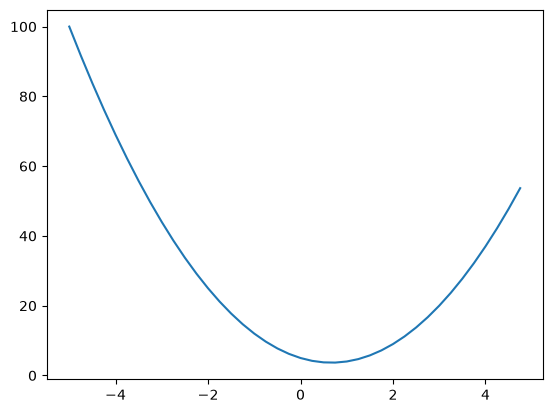

In [24]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)

In [25]:
h = 0.0000001
x = -3.0
(f(x + h) - f(x))/h

-21.999999688659955

In [26]:
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
c += h
d2 = a*b + c

print('d1: ', d1)
print('d2: ', d2)
print('slope', (d2-d1)/h)

d1:  4.0
d2:  4.000000099999999
slope 0.999999993922529


In [ ]:
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self._prev = set(_children)
        self.grad = 0.0
        self._backward = lambda: None
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad = 1.0 * out.grad
            other.grad = 1.0 * out.grad
        out._backward = _backward

        return out

    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad  = other.data * out.grad
            other.grad = self.data * out.grad
        out._backward = _backward

        return out

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)

        out = Value(t, (self, ), 'tanh')

        def _backward():
            self.grad = (1 - t**2) * out.grad
        out._backward = _backward

        return out

In [28]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()

    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)

    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))

        # create square node to each variable
        dot.node(name = uid, label = "{%s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')

        if n._op:
            dot.node(name = uid + n._op, label = n._op)
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

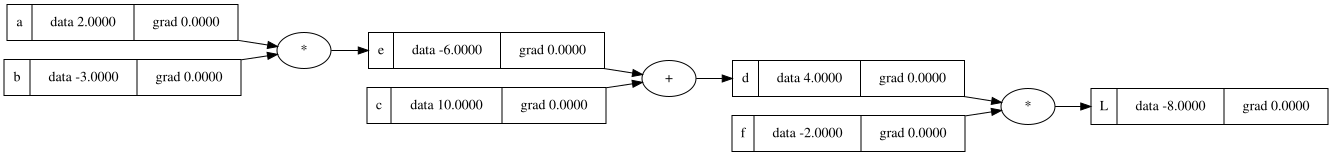

In [29]:
draw_dot(L)

In [30]:
L.grad = 1.0   
d.grad = -2.0  # dL/dd 
f.grad = 4.0   # dL/df
e.grad = -2.0  # dL/de = dd/de * dL/dd
c.grad = -2.0  # dL/dc = dd/dx * dL/dd
a.grad = 6.0   # dL/da = de/da * dd/de * dL/dd (where dL/de = dd/de * dL/dd)
b.grad = -4.0  # dL/db = de/db * dd/de * dL/dd (where dL/de = dd/de * dL/dd)

In [31]:
lr = 0.0001
a.data += lr * a.grad
b.data += lr * b.grad
c.data += lr * c.grad
f.data += lr * f.grad

e = a * b
d = e + c
L = d * f
L

Value(data=-7.992800640096002)

In [32]:
def lol():
    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a * b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L1 = L.data

    a = Value(2.0, label='a')
    b = Value(-3.0 + h, label='b')
    c = Value(10.0, label='c')
    e = a * b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L2 = L.data

    print((L2 - L1)/h)

lol()

-3.9999999934536845


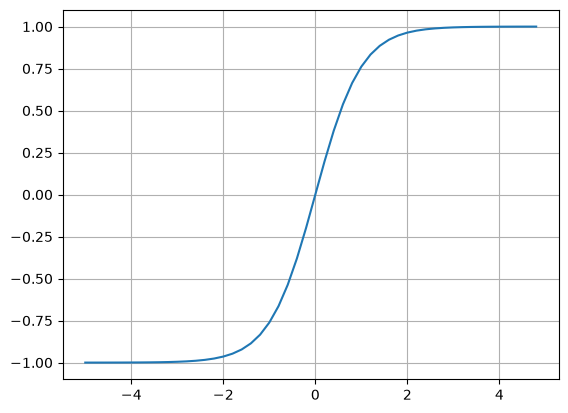

In [33]:
plt.plot(np.arange(-5,5,0.2), np.tanh(np.arange(-5,5,0.2))); plt.grid();

In [81]:
x1 = Value(2.0, label='x1')
x2 = Value(1.0, label='x2')

w1 = Value(-2.0, label='w1')
w2 = Value(3.0, label='w2')

b = Value(2.0, label='b')

x1w1 = x1 * w1; x1w1.label ='x1w1'
x2w2 = x2 * w2; x2w2.label ='x2w2'

x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label='x1w1+x2w2'

n = x1w1x2w2 + b; n.label='n'

o = n.tanh(); o.label='o'


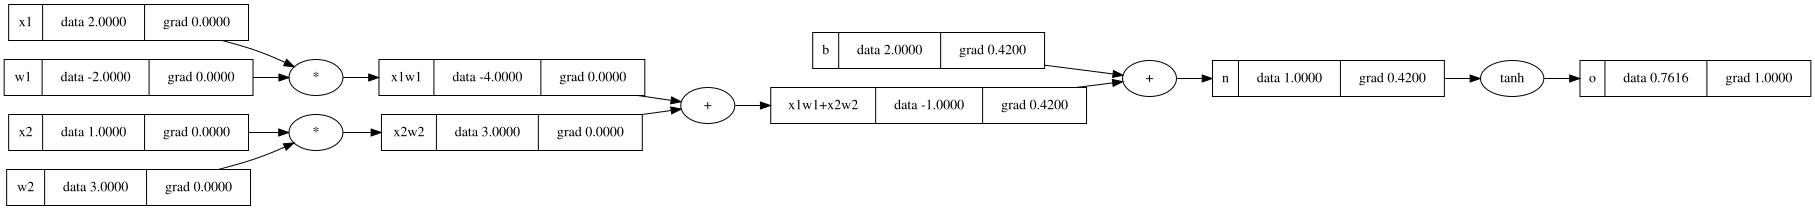

In [84]:
draw_dot(o)

In [83]:
o.grad=1.0
o._backward()
n._backward()